# Employee Attrition Prediction & Retention Strategy

## 👥 Business Context

Employee turnover is costly, affecting productivity, morale, and the bottom line. This analysis uses advanced machine learning and survival analysis to predict which employees are at risk of leaving and identifying the key drivers of attrition to formulate targeted retention strategies.

## 📊 Objectives

1. Predict employee attrition risk using classification models
2. Analyze survival curves to understand tenure dynamics
3. Identify key drivers of turnover using SHAP values
4. Segment employees by risk profile
5. Recommend personalized retention interventions

## 🔧 Methodology

- **Techniques**: Random Forest, Survival Analysis (Kaplan-Meier, Cox Proportional Hazards), SHAP (SHapley Additive exPlanations)
- **Metrics**: Accuracy, Recall, Concordance Index, Lift
- **Data**: Synthetic HR dataset (demographics, job role, satisfaction, compensation)

In [6]:
# Install packages
!pip install pandas numpy matplotlib seaborn scikit-learn lifelines shap

In [7]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lifelines import KaplanMeierFitter, CoxPHFitter
import shap
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('mako')
%matplotlib inline

print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


## 1. Data Generation

Creating a realistic HR dataset with factors commonly associated with attrition.

In [8]:
def generate_hr_data(n_employees=2000):
    """
    Generate synthetic employee data.
    """
    np.random.seed(42)
    
    # Basic details
    ids = range(1, n_employees + 1)
    age = np.random.normal(35, 8, n_employees).astype(int)
    age = np.clip(age, 20, 60)
    
    # Job details
    departments = np.random.choice(['Sales', 'R&D', 'HR'], n_employees, p=[0.3, 0.6, 0.1])
    roles = np.random.choice(['Junior', 'Senior', 'Manager', 'Director'], n_employees, p=[0.4, 0.35, 0.2, 0.05])
    distance = np.random.exponential(10, n_employees).astype(int) + 1
    
    # Satisfaction and Performance
    job_satisfaction = np.random.choice([1, 2, 3, 4], n_employees, p=[0.1, 0.2, 0.4, 0.3])
    env_satisfaction = np.random.choice([1, 2, 3, 4], n_employees, p=[0.1, 0.2, 0.4, 0.3])
    performance = np.random.choice([3, 4], n_employees, p=[0.8, 0.2])
    
    # Compensation, keep as NumPy array
    monthly_income = np.zeros(n_employees, dtype=int)
    for i, r in enumerate(roles):
        if r == 'Junior':
            base = 3000
        elif r == 'Senior':
            base = 6000
        elif r == 'Manager':
            base = 12000
        else:
            base = 18000
        monthly_income[i] = int(np.random.normal(base, base * 0.1))
    
    # Tenure
    years_at_company = np.random.exponential(5, n_employees).astype(int)
    years_at_company = np.clip(years_at_company, 0, 40)
    years_since_promotion = np.minimum(
        years_at_company,
        np.random.exponential(3, n_employees).astype(int)
    )
    
    # Attrition Logic (Probabilistic)
    attrition_prob = np.zeros(n_employees)
    attrition_prob += (4 - job_satisfaction) * 0.15
    attrition_prob += (4 - env_satisfaction) * 0.1
    attrition_prob += (distance > 20) * 0.1
    attrition_prob += (years_since_promotion > 5) * 0.2
    attrition_prob += (monthly_income < 4000) * 0.1
    attrition_prob += (age < 30) * 0.1
    attrition_prob = np.clip(attrition_prob, 0.05, 0.9)
    
    attrition = np.random.binomial(1, attrition_prob)
    
    df = pd.DataFrame({
        'EmployeeID': ids,
        'Age': age,
        'Department': departments,
        'JobRole': roles,
        'DistanceFromHome': distance,
        'JobSatisfaction': job_satisfaction,
        'EnvironmentSatisfaction': env_satisfaction,
        'PerformanceRating': performance,
        'MonthlyIncome': monthly_income,
        'YearsAtCompany': years_at_company,
        'YearsSinceLastPromotion': years_since_promotion,
        'Attrition': attrition
    })
    
    return df


df = generate_hr_data()
print(f"Dataset Shape: {df.shape}")
print(f"Attrition Rate: {df['Attrition'].mean():.1%}")
df.head()


Dataset Shape: (2000, 12)
Attrition Rate: 38.6%


,EmployeeID,Age,Department,JobRole,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,PerformanceRating,MonthlyIncome,YearsAtCompany,YearsSinceLastPromotion,Attrition
0,1,38,R&D,Senior,2,3,2,3,7150,1,1,0
1,2,33,Sales,Manager,6,1,2,4,12994,0,0,1
2,3,40,R&D,Manager,5,4,3,3,11109,3,1,0
3,4,47,Sales,Junior,8,1,3,3,2885,0,0,1
4,5,33,R&D,Junior,9,3,3,3,3176,3,3,1


## 2. Exploratory Data Analysis (EDA)

Analyzing relationships between features and attrition.

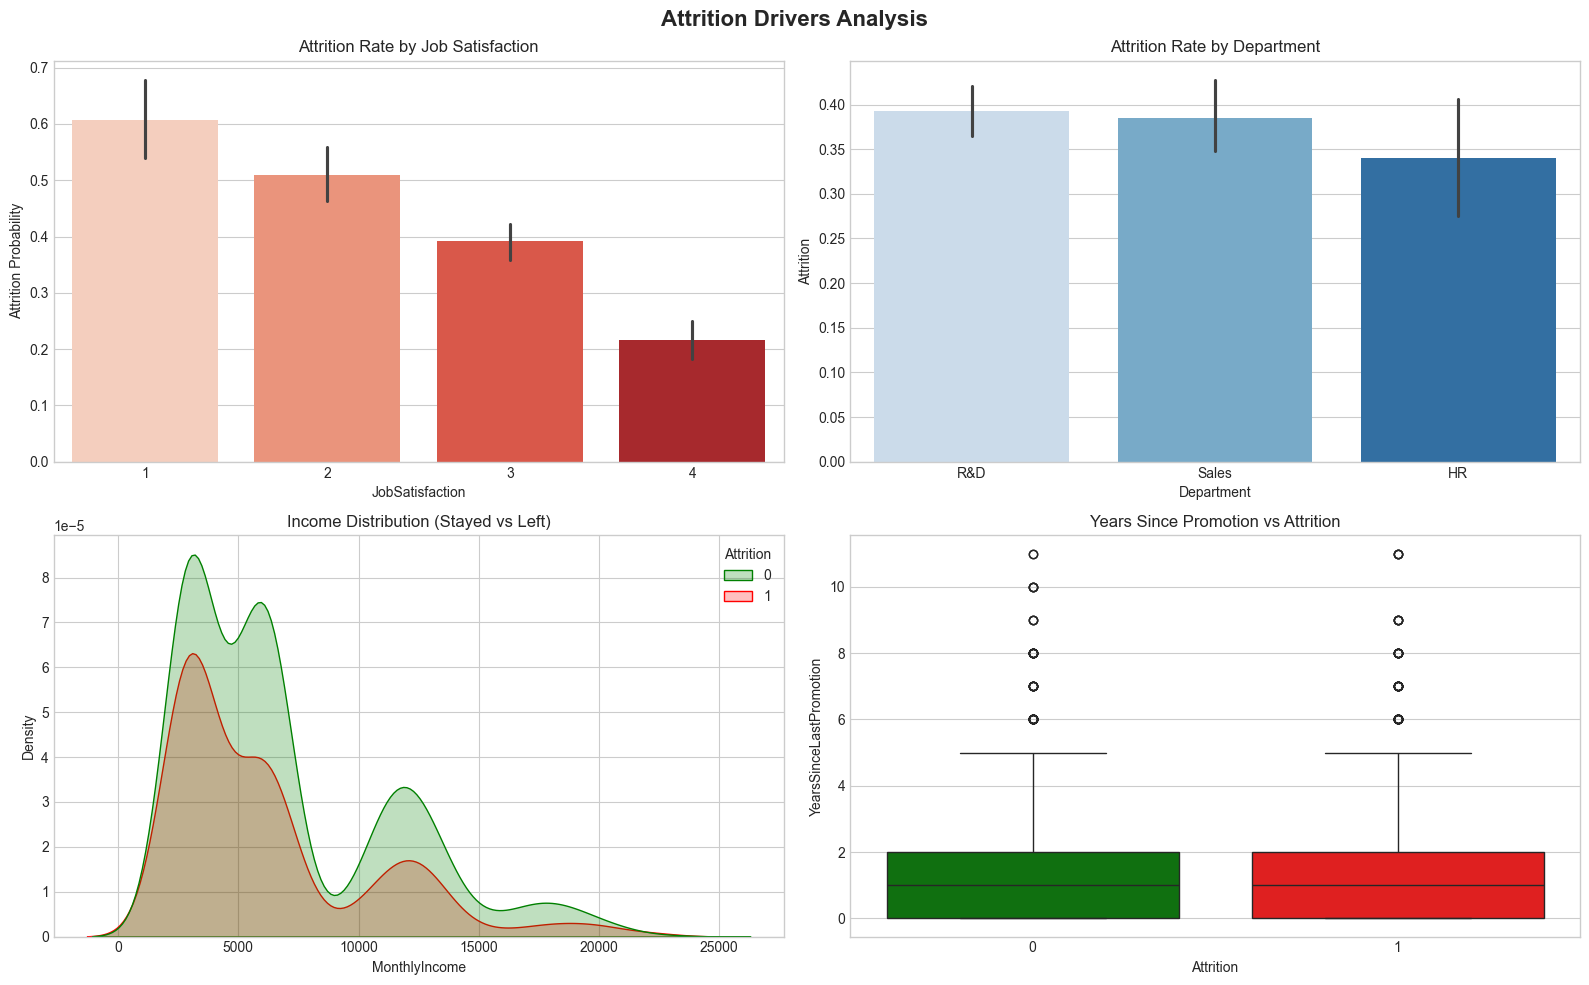

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Attrition Drivers Analysis', fontsize=16, fontweight='bold')

# Job Satisfaction vs Attrition
sns.barplot(x='JobSatisfaction', y='Attrition', data=df, ax=axes[0, 0], palette='Reds')
axes[0, 0].set_title('Attrition Rate by Job Satisfaction')
axes[0, 0].set_ylabel('Attrition Probability')

# Department vs Attrition
sns.barplot(x='Department', y='Attrition', data=df, ax=axes[0, 1], palette='Blues')
axes[0, 1].set_title('Attrition Rate by Department')

# Income Distribution
sns.kdeplot(data=df, x='MonthlyIncome', hue='Attrition', fill=True, ax=axes[1, 0], palette=['green', 'red'])
axes[1, 0].set_title('Income Distribution (Stayed vs Left)')

# Years Since Promotion
sns.boxplot(x='Attrition', y='YearsSinceLastPromotion', data=df, ax=axes[1, 1], palette=['green', 'red'])
axes[1, 1].set_title('Years Since Promotion vs Attrition')

plt.tight_layout()
plt.savefig('outputs/eda_attrition.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Survival Analysis

Using Kaplan-Meier curves to estimate employee retention over time.

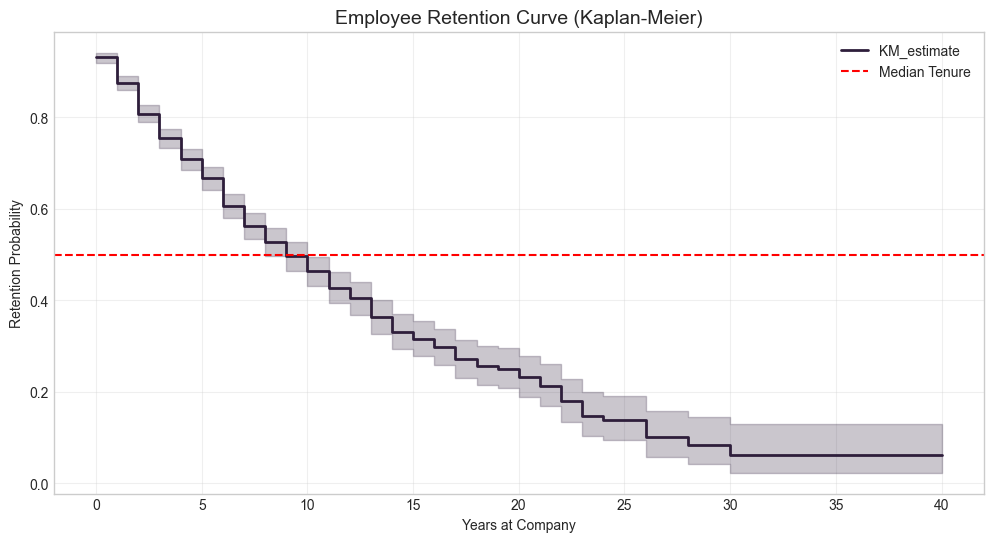

Median Retention Time: 9.0 years


In [10]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(12, 6))

# Fit data
kmf.fit(durations=df['YearsAtCompany'], event_observed=df['Attrition'])

# Plot
kmf.plot_survival_function(linewidth=2)
plt.title('Employee Retention Curve (Kaplan-Meier)', fontsize=14)
plt.xlabel('Years at Company')
plt.ylabel('Retention Probability')
plt.grid(True, alpha=0.3)
plt.axhline(0.5, color='red', linestyle='--', label='Median Tenure')
plt.legend()
plt.savefig('outputs/survival_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Median Retention Time: {kmf.median_survival_time_:.1f} years")

## 4. Predictive Modeling (Random Forest)

Building a classifier to predict attrition risk.

In [11]:
# Preprocessing
le = LabelEncoder()
df_model = df.copy()
for col in ['Department', 'JobRole']:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(['EmployeeID', 'Attrition'], axis=1)
y = df_model['Attrition']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.83      0.75       369
           1       0.58      0.36      0.45       231

    accuracy                           0.65       600
   macro avg       0.63      0.60      0.60       600
weighted avg       0.64      0.65      0.63       600

ROC-AUC Score: 0.708


## 5. Explainability with SHAP

Understanding individual and global drivers of attrition.

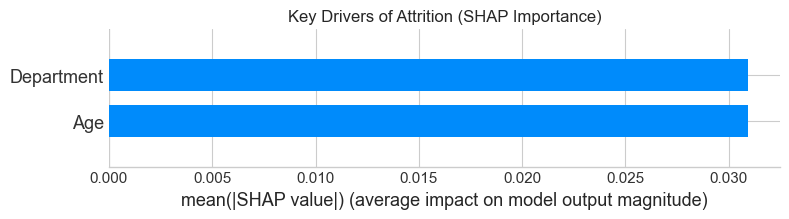

In [17]:
# SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# For binary classification use the positive class
sv = shap_values[1]

# Some SHAP versions add an extra constant-offset column, drop it if present
if sv.shape[1] > X_test.shape[1]:
    sv = sv[:, :-1]

# Summary bar plot, pass only shap values and feature names
plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv,
    feature_names=X_test.columns,
    plot_type="bar",
    show=False
)
plt.title("Key Drivers of Attrition (SHAP Importance)")
plt.tight_layout()
plt.savefig("outputs/shap_importance.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Recommendations

Targeted strategies based on risk profiles.

In [16]:
print("="*80)
print("RETENTION STRATEGY")
print("="*80)

print("\n1. HIGH RISK GROUP (Probability > 70%)")
print("   • Immediate 1-on-1 career conversation")
print("   • Review compensation competitiveness")
print("   • Address specific dissatisfaction (e.g., promotion stagnation)")

print("\n2. SYSTEMIC ISSUES")
print("   • 'Years Since Last Promotion' is a top driver.")
print("   • Recommendation: Implement rotation program for employees stuck >4 years.")

print("\n3. NEW HIRES")
print("   • Survival curve shows steep drop in first 2 years.")
print("   • Recommendation: Enhance onboarding and mentorship for first 18 months.")

RETENTION STRATEGY

1. HIGH RISK GROUP (Probability > 70%)
   • Immediate 1-on-1 career conversation
   • Review compensation competitiveness
   • Address specific dissatisfaction (e.g., promotion stagnation)

2. SYSTEMIC ISSUES
   • 'Years Since Last Promotion' is a top driver.
   • Recommendation: Implement rotation program for employees stuck >4 years.

3. NEW HIRES
   • Survival curve shows steep drop in first 2 years.
   • Recommendation: Enhance onboarding and mentorship for first 18 months.
